<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/notebooks/sd/ddpm_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from torch.utils.data import DataLoader, TensorDataset, Dataset

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


In [2]:
def create_1d_swissroll_data(n_samples=1000):
    """Create 1D Swiss roll data by projecting 3D Swiss roll to 1D"""
    # Generate 3D Swiss roll
    X_3d, color = make_swiss_roll(n_samples=n_samples, noise=0.1, random_state=42)

    # Project to 1D using the first principal component or simple projection
    # Here we'll use the x-coordinate which captures the spiral structure well
    X_1d = X_3d[:, 0].reshape(-1, 1)  # Shape: (n_samples, 1)

    # Normalize to [-1, 1]
    X_1d = (X_1d - X_1d.mean()) / X_1d.std()
    X_1d = np.clip(X_1d, -3, 3)  # Clip outliers

    return X_1d.astype(np.float32), color


In [3]:
swiss_roll_dataset = create_1d_swissroll_data(n_samples=100)
print(type(swiss_roll_dataset))

<class 'tuple'>


In [4]:
# print(swiss_roll_dataset)
features = torch.tensor(swiss_roll_dataset[0])
labels = torch.tensor(swiss_roll_dataset[1])

In [5]:
print(features.shape)
print(labels.shape)

torch.Size([100, 1])
torch.Size([100])


In [6]:
# print(labels)

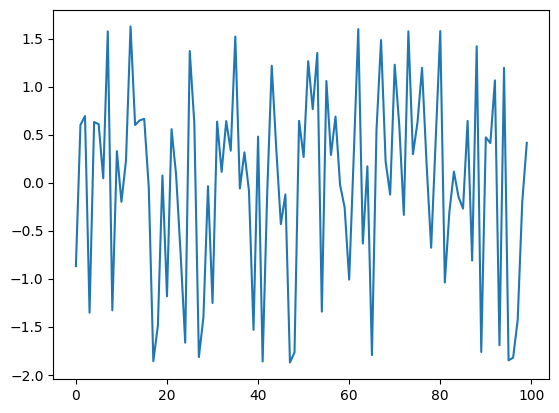

In [7]:
plt.plot(features)

In [8]:
torch.linspace(0, 100, 5)

tensor([  0.,  25.,  50.,  75., 100.])

In [9]:
# Adhira is experimenting
tmin, tmax, N = np.pi/2, 5*np.pi, 100

In [10]:
print(f"tmin: {tmin:.2f}, tmax: {tmax:.2f}, N: {N}")

tmin: 1.57, tmax: 15.71, N: 100


tensor([0.0000, 0.0101, 0.0202, 0.0303, 0.0404, 0.0505, 0.0606, 0.0707, 0.0808,
        0.0909, 0.1010, 0.1111, 0.1212, 0.1313, 0.1414, 0.1515, 0.1616, 0.1717,
        0.1818, 0.1919, 0.2020, 0.2121, 0.2222, 0.2323, 0.2424, 0.2525, 0.2626,
        0.2727, 0.2828, 0.2929, 0.3030, 0.3131, 0.3232, 0.3333, 0.3434, 0.3535,
        0.3636, 0.3737, 0.3838, 0.3939, 0.4040, 0.4141, 0.4242, 0.4343, 0.4444,
        0.4545, 0.4646, 0.4747, 0.4848, 0.4949, 0.5051, 0.5152, 0.5253, 0.5354,
        0.5455, 0.5556, 0.5657, 0.5758, 0.5859, 0.5960, 0.6061, 0.6162, 0.6263,
        0.6364, 0.6465, 0.6566, 0.6667, 0.6768, 0.6869, 0.6970, 0.7071, 0.7172,
        0.7273, 0.7374, 0.7475, 0.7576, 0.7677, 0.7778, 0.7879, 0.7980, 0.8081,
        0.8182, 0.8283, 0.8384, 0.8485, 0.8586, 0.8687, 0.8788, 0.8889, 0.8990,
        0.9091, 0.9192, 0.9293, 0.9394, 0.9495, 0.9596, 0.9697, 0.9798, 0.9899,
        1.0000])
torch.Size([100])
tensor(0.)
tensor(1.)


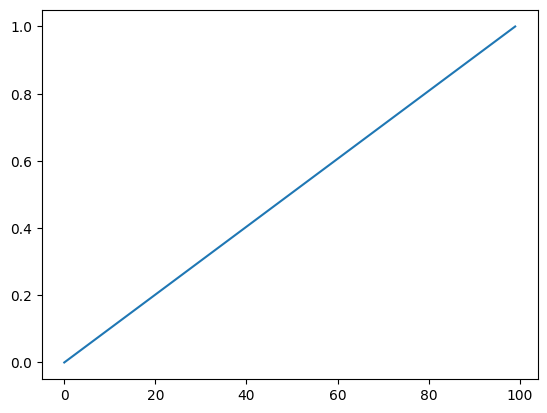

In [11]:
linear_graph = torch.linspace(0, 1, N)
print(linear_graph)
print(linear_graph.shape)
print(linear_graph.min())
print(linear_graph.max())
plt.plot(linear_graph)

In [12]:

t = tmin + (torch.linspace(0,1,N))*tmax
print(t)

tensor([ 1.5708,  1.7295,  1.8881,  2.0468,  2.2055,  2.3641,  2.5228,  2.6815,
         2.8401,  2.9988,  3.1575,  3.3161,  3.4748,  3.6335,  3.7921,  3.9508,
         4.1095,  4.2681,  4.4268,  4.5855,  4.7441,  4.9028,  5.0615,  5.2201,
         5.3788,  5.5375,  5.6961,  5.8548,  6.0135,  6.1721,  6.3308,  6.4895,
         6.6481,  6.8068,  6.9655,  7.1241,  7.2828,  7.4414,  7.6001,  7.7588,
         7.9174,  8.0761,  8.2348,  8.3934,  8.5521,  8.7108,  8.8694,  9.0281,
         9.1868,  9.3454,  9.5041,  9.6628,  9.8214,  9.9801, 10.1388, 10.2974,
        10.4561, 10.6148, 10.7734, 10.9321, 11.0908, 11.2494, 11.4081, 11.5668,
        11.7254, 11.8841, 12.0428, 12.2014, 12.3601, 12.5188, 12.6774, 12.8361,
        12.9948, 13.1534, 13.3121, 13.4708, 13.6294, 13.7881, 13.9468, 14.1054,
        14.2641, 14.4228, 14.5814, 14.7401, 14.8988, 15.0574, 15.2161, 15.3748,
        15.5334, 15.6921, 15.8508, 16.0094, 16.1681, 16.3268, 16.4854, 16.6441,
        16.8028, 16.9614, 17.1201, 17.27

In [13]:
print(t.shape)
print(t.min())
print(t.max())

torch.Size([100])
tensor(1.5708)
tensor(17.2788)


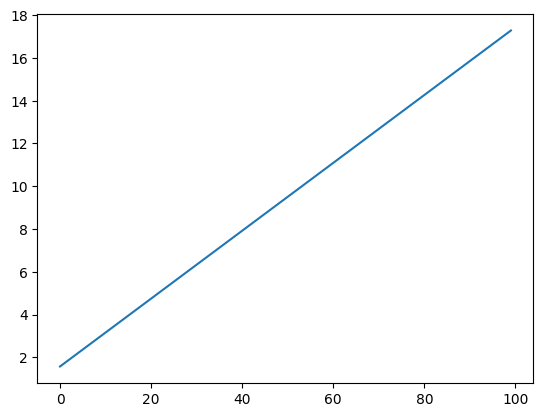

In [14]:
plt.plot(t)

In [15]:
center = (0,0)
print(type(center))
center_tensor = torch.tensor(center)
print(center_tensor)
print(type(center_tensor))

<class 'tuple'>
tensor([0, 0])
<class 'torch.Tensor'>


In [16]:
center_tensor_unsqueeze = center_tensor.unsqueeze(0)
print(center_tensor_unsqueeze)
print(center_tensor_unsqueeze.shape)

tensor([[0, 0]])
torch.Size([1, 2])


In [17]:
print(center_tensor.shape)

torch.Size([2])


In [18]:
scale = 1.0

In [19]:
# vals = center + scale * torch.stack([t*torch.cos(t)/tmax, t*torch.sin(t)/tmax]).T

In [20]:
linear_graph_reverse = torch.linspace(1, 0, N)

In [21]:
print(linear_graph_reverse)

tensor([1.0000, 0.9899, 0.9798, 0.9697, 0.9596, 0.9495, 0.9394, 0.9293, 0.9192,
        0.9091, 0.8990, 0.8889, 0.8788, 0.8687, 0.8586, 0.8485, 0.8384, 0.8283,
        0.8182, 0.8081, 0.7980, 0.7879, 0.7778, 0.7677, 0.7576, 0.7475, 0.7374,
        0.7273, 0.7172, 0.7071, 0.6970, 0.6869, 0.6768, 0.6667, 0.6566, 0.6465,
        0.6364, 0.6263, 0.6162, 0.6061, 0.5960, 0.5859, 0.5758, 0.5657, 0.5556,
        0.5455, 0.5354, 0.5253, 0.5152, 0.5051, 0.4949, 0.4848, 0.4747, 0.4646,
        0.4545, 0.4444, 0.4343, 0.4242, 0.4141, 0.4040, 0.3939, 0.3838, 0.3737,
        0.3636, 0.3535, 0.3434, 0.3333, 0.3232, 0.3131, 0.3030, 0.2929, 0.2828,
        0.2727, 0.2626, 0.2525, 0.2424, 0.2323, 0.2222, 0.2121, 0.2020, 0.1919,
        0.1818, 0.1717, 0.1616, 0.1515, 0.1414, 0.1313, 0.1212, 0.1111, 0.1010,
        0.0909, 0.0808, 0.0707, 0.0606, 0.0505, 0.0404, 0.0303, 0.0202, 0.0101,
        0.0000])


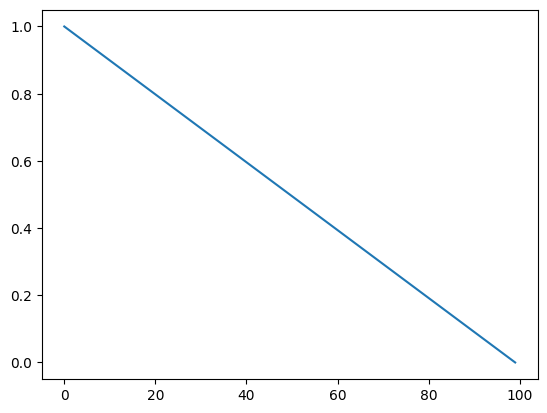

In [22]:
plt.plot(linear_graph_reverse)

In [23]:
treverse = tmin + (torch.linspace(1,0,N))*tmax
print(treverse)

tensor([17.2788, 17.1201, 16.9614, 16.8028, 16.6441, 16.4854, 16.3268, 16.1681,
        16.0094, 15.8508, 15.6921, 15.5334, 15.3748, 15.2161, 15.0574, 14.8988,
        14.7401, 14.5814, 14.4228, 14.2641, 14.1054, 13.9468, 13.7881, 13.6294,
        13.4708, 13.3121, 13.1534, 12.9948, 12.8361, 12.6774, 12.5188, 12.3601,
        12.2014, 12.0428, 11.8841, 11.7254, 11.5668, 11.4081, 11.2494, 11.0908,
        10.9321, 10.7734, 10.6148, 10.4561, 10.2974, 10.1388,  9.9801,  9.8214,
         9.6628,  9.5041,  9.3454,  9.1868,  9.0281,  8.8694,  8.7108,  8.5521,
         8.3934,  8.2348,  8.0761,  7.9174,  7.7588,  7.6001,  7.4414,  7.2828,
         7.1241,  6.9655,  6.8068,  6.6481,  6.4895,  6.3308,  6.1721,  6.0135,
         5.8548,  5.6961,  5.5375,  5.3788,  5.2201,  5.0615,  4.9028,  4.7441,
         4.5855,  4.4268,  4.2681,  4.1095,  3.9508,  3.7921,  3.6335,  3.4748,
         3.3161,  3.1575,  2.9988,  2.8401,  2.6815,  2.5228,  2.3641,  2.2055,
         2.0468,  1.8881,  1.7295,  1.57

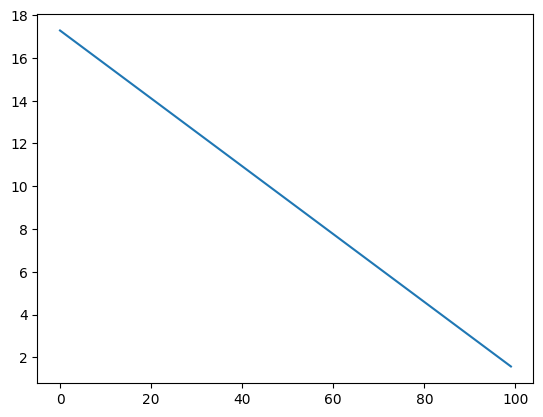

In [24]:
plt.plot(treverse)

In [25]:
x_y_dataset = torch.stack(
    [torch.cos(treverse), torch.sin(treverse)]
)
print(x_y_dataset)

tensor([[-5.9206e-07, -1.5800e-01, -3.1203e-01, -4.5823e-01, -5.9291e-01,
         -7.1269e-01, -8.1458e-01, -8.9599e-01, -9.5490e-01, -9.8982e-01,
         -9.9987e-01, -9.8481e-01, -9.4500e-01, -8.8145e-01, -7.9576e-01,
         -6.9008e-01, -5.6706e-01, -4.2979e-01, -2.8173e-01, -1.2659e-01,
          3.1729e-02,  1.8925e-01,  3.4202e-01,  4.8620e-01,  6.1816e-01,
          7.3459e-01,  8.3257e-01,  9.0963e-01,  9.6384e-01,  9.9384e-01,
          9.9887e-01,  9.7880e-01,  9.3415e-01,  8.6603e-01,  7.7615e-01,
          6.6677e-01,  5.4064e-01,  4.0093e-01,  2.5115e-01,  9.5056e-02,
         -6.3425e-02, -2.2031e-01, -3.7166e-01, -5.1368e-01, -6.4279e-01,
         -7.5575e-01, -8.4973e-01, -9.2235e-01, -9.7181e-01, -9.9685e-01,
         -9.9685e-01, -9.7181e-01, -9.2235e-01, -8.4973e-01, -7.5575e-01,
         -6.4279e-01, -5.1368e-01, -3.7166e-01, -2.2031e-01, -6.3424e-02,
          9.5056e-02,  2.5115e-01,  4.0093e-01,  5.4064e-01,  6.6677e-01,
          7.7615e-01,  8.6603e-01,  9.

In [26]:
print(x_y_dataset.shape)

torch.Size([2, 100])


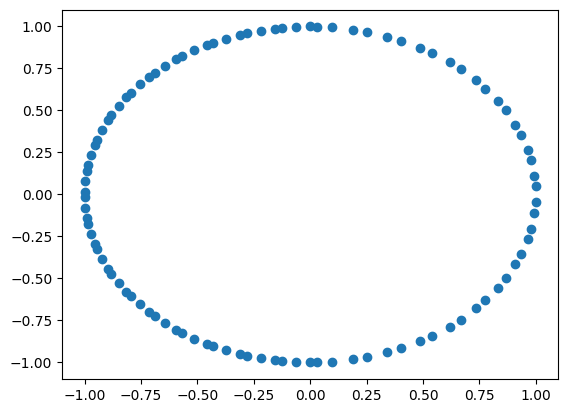

In [27]:
plt.scatter(x_y_dataset[0], x_y_dataset[1])

In [28]:
x_y_dataset_norm = torch.stack(
    [torch.cos(treverse)/tmax, torch.sin(treverse)/tmax]
)
print(x_y_dataset_norm)

tensor([[-3.7692e-08, -1.0059e-02, -1.9865e-02, -2.9172e-02, -3.7746e-02,
         -4.5372e-02, -5.1858e-02, -5.7041e-02, -6.0791e-02, -6.3014e-02,
         -6.3654e-02, -6.2695e-02, -6.0161e-02, -5.6115e-02, -5.0660e-02,
         -4.3932e-02, -3.6100e-02, -2.7362e-02, -1.7936e-02, -8.0591e-03,
          2.0199e-03,  1.2048e-02,  2.1774e-02,  3.0952e-02,  3.9353e-02,
          4.6766e-02,  5.3003e-02,  5.7909e-02,  6.1360e-02,  6.3270e-02,
          6.3590e-02,  6.2312e-02,  5.9470e-02,  5.5133e-02,  4.9411e-02,
          4.2448e-02,  3.4418e-02,  2.5524e-02,  1.5989e-02,  6.0514e-03,
         -4.0377e-03, -1.4025e-02, -2.3661e-02, -3.2702e-02, -4.0921e-02,
         -4.8113e-02, -5.4095e-02, -5.8719e-02, -6.1867e-02, -6.3462e-02,
         -6.3462e-02, -6.1867e-02, -5.8719e-02, -5.4095e-02, -4.8112e-02,
         -4.0921e-02, -3.2702e-02, -2.3661e-02, -1.4025e-02, -4.0377e-03,
          6.0515e-03,  1.5989e-02,  2.5524e-02,  3.4418e-02,  4.2448e-02,
          4.9411e-02,  5.5133e-02,  5.

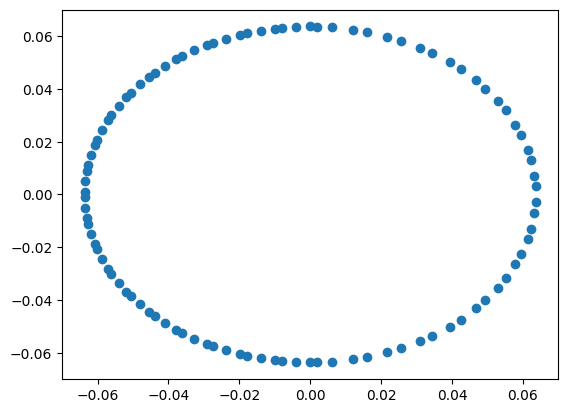

In [29]:
plt.scatter(x_y_dataset_norm[0], x_y_dataset_norm[1])

In [30]:
x_y_dataset_treverse = torch.stack(
    [treverse*torch.cos(treverse)/tmax, treverse*torch.sin(treverse)/tmax]
)
print(x_y_dataset_treverse)

tensor([[-6.5126e-07, -1.7221e-01, -3.3693e-01, -4.9016e-01, -6.2824e-01,
         -7.4797e-01, -8.4667e-01, -9.2224e-01, -9.7323e-01, -9.9882e-01,
         -9.9886e-01, -9.7387e-01, -9.2496e-01, -8.5385e-01, -7.6281e-01,
         -6.5453e-01, -5.3212e-01, -3.9897e-01, -2.5868e-01, -1.1496e-01,
          2.8492e-02,  1.6803e-01,  3.0022e-01,  4.2186e-01,  5.3012e-01,
          6.2255e-01,  6.9717e-01,  7.5251e-01,  7.8762e-01,  8.0210e-01,
          7.9607e-01,  7.7019e-01,  7.2562e-01,  6.6395e-01,  5.8721e-01,
          4.9772e-01,  3.9811e-01,  2.9118e-01,  1.7986e-01,  6.7115e-02,
         -4.4141e-02, -1.5110e-01, -2.5115e-01, -3.4193e-01, -4.2138e-01,
         -4.8780e-01, -5.3988e-01, -5.7670e-01, -5.9781e-01, -6.0315e-01,
         -5.9308e-01, -5.6836e-01, -5.3012e-01, -4.7979e-01, -4.1910e-01,
         -3.4996e-01, -2.7448e-01, -1.9484e-01, -1.1327e-01, -3.1968e-02,
          4.6952e-02,  1.2151e-01,  1.8994e-01,  2.5066e-01,  3.0240e-01,
          3.4417e-01,  3.7528e-01,  3.

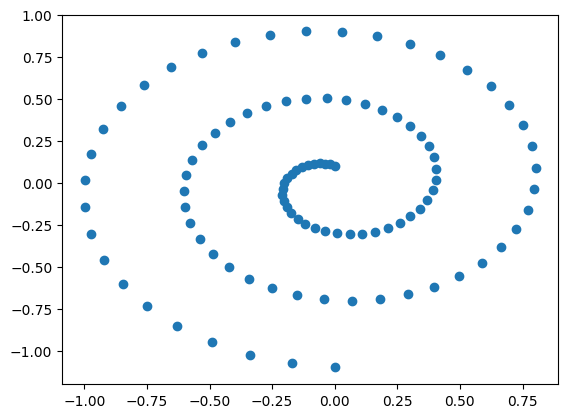

In [31]:
plt.scatter(x_y_dataset_treverse[0], x_y_dataset_treverse[1])

tensor([[ 1.0000e-01,  1.0872e-01,  1.1420e-01,  1.1582e-01,  1.1306e-01,
          1.0558e-01,  9.3161e-02,  7.5805e-02,  5.3686e-02,  2.7169e-02,
         -3.1892e-03, -3.6659e-02, -7.2351e-02, -1.0924e-01, -1.4620e-01,
         -1.8203e-01, -2.1549e-01, -2.4534e-01, -2.7040e-01, -2.8957e-01,
         -3.0187e-01, -3.0648e-01, -3.0279e-01, -2.9040e-01, -2.6916e-01,
         -2.3919e-01, -2.0087e-01, -1.5484e-01, -1.0201e-01, -4.3551e-02,
          1.9177e-02,  8.4612e-02,  1.5105e-01,  2.1667e-01,  2.7961e-01,
          3.3800e-01,  3.9004e-01,  4.3399e-01,  4.6833e-01,  4.9170e-01,
          5.0303e-01,  5.0151e-01,  4.8669e-01,  4.5846e-01,  4.1707e-01,
          3.6315e-01,  2.9770e-01,  2.2205e-01,  1.3788e-01,  4.7150e-02,
         -4.7950e-02, -1.4503e-01, -2.4156e-01, -3.3497e-01, -4.2268e-01,
         -5.0218e-01, -5.7112e-01, -6.2735e-01, -6.6901e-01, -6.9456e-01,
         -7.0286e-01, -6.9321e-01, -6.6534e-01, -6.1947e-01, -5.5631e-01,
         -4.7705e-01, -3.8333e-01, -2.

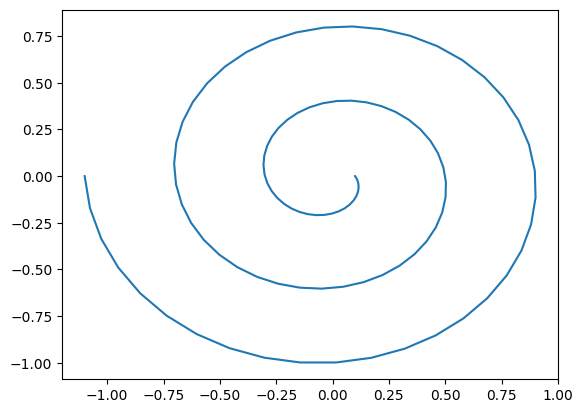

In [32]:
x_y_dataset_original = torch.stack(
    [
        t*torch.sin(t)/tmax, t*torch.cos(t)/tmax
    ]
)
print(x_y_dataset_original)
plt.plot(x_y_dataset_original[0], x_y_dataset_original[1])

In [33]:
# print(type(x_y_dataset_original))
print(x_y_dataset_original.shape)
x_y_dataset_original_transpose = x_y_dataset_original.T
# print(x_y_dataset_original_transpose)
# print(type(x_y_dataset_original_transpose))
print(x_y_dataset_original_transpose.shape)

torch.Size([2, 100])
torch.Size([100, 2])


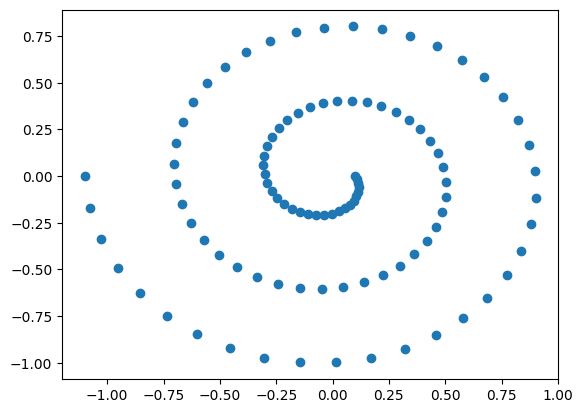

In [34]:
plt.scatter(x_y_dataset_original_transpose[:,0], x_y_dataset_original_transpose[:,1])

In [35]:
print(scale)

1.0


In [36]:
x_y_dataset_original_transpose_scaled = x_y_dataset_original_transpose * scale
print(x_y_dataset_original_transpose_scaled.max())
print(x_y_dataset_original_transpose_scaled.min())

tensor(0.9008)
tensor(-1.1000)


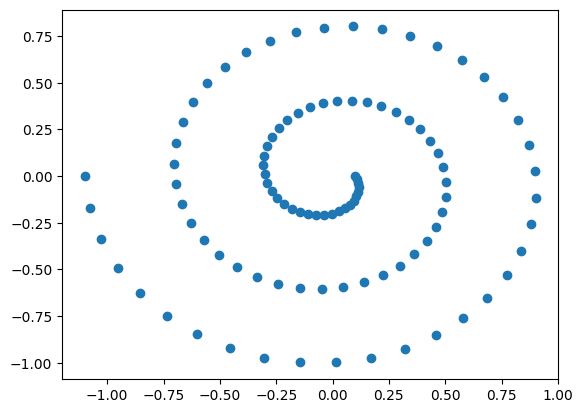

In [37]:
plt.scatter(x_y_dataset_original_transpose_scaled[:,0], x_y_dataset_original_transpose_scaled[:,1])

In [38]:
print(type(center_tensor))
print(type(x_y_dataset_original_transpose_scaled))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [39]:
x_y_dataset_original_transpose_scaled_center = center_tensor + x_y_dataset_original_transpose_scaled
print(x_y_dataset_original_transpose_scaled_center.max())
print(x_y_dataset_original_transpose_scaled_center.min())

tensor(0.9008)
tensor(-1.1000)


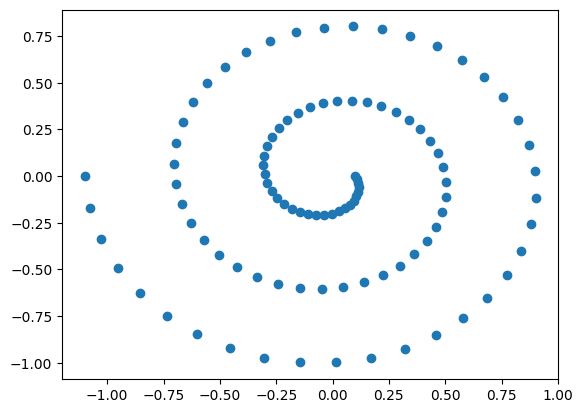

In [40]:
plt.scatter(x_y_dataset_original_transpose_scaled_center[:,0], x_y_dataset_original_transpose_scaled_center[:,1])

In [41]:
print(center_tensor)
print(center)

tensor([0, 0])
(0, 0)


In [42]:
new_center = (9,37)
new_center_tensor = torch.tensor(new_center)
print(new_center_tensor)


tensor([ 9, 37])


In [43]:
x_y_dataset_original_transpose_scaled_center_new = new_center_tensor + x_y_dataset_original_transpose_scaled
print(x_y_dataset_original_transpose_scaled_center_new.max())
print(x_y_dataset_original_transpose_scaled_center_new.min())

tensor(37.8021)
tensor(7.9000)


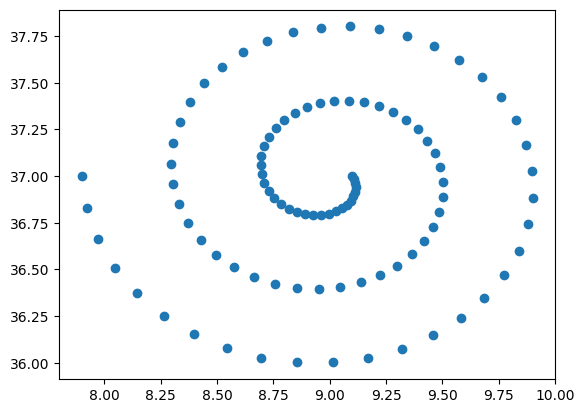

In [44]:
plt.scatter(x_y_dataset_original_transpose_scaled_center_new[:,0], x_y_dataset_original_transpose_scaled_center_new[:,1])

In [45]:

class SwissRollDataset(Dataset):
    def __init__(self, tmin, tmax, N=100, scale=1.0, center=(0,0)) -> None:
        super().__init__()
        # Create SwissRollDataset
        # 1. Create linespace
        # 2. Create center tensor and unsqueeze it (resize dimension)
        # 3. Create sin cos swirl
        # 4. Normalize, center and scale
        linegraph = torch.linspace(tmin, tmax, N)
        t = tmin + linear_graph*tmax
        center_tensor_unsqueezed = torch.tensor(center).unsqueeze(0)
        swirl = torch.stack(
            [
                t*torch.sin(t)/tmax, t*torch.cos(t)/tmax
            ]
        )
        self.swirl_transformed = center_tensor_unsqueezed + (swirl.T * scale)
    def __len__(self):
      return len(self.swirl_transformed)
    def __getitem__(self, idx):
      return self.swirl_transformed[idx]

In [46]:
tmin, tmax, N = np.pi/2, 5*np.pi, 100
swissroll_dataset = SwissRollDataset(tmin, tmax, N=100, scale=1.0, center=(0,0))

In [47]:
print(type(swissroll_dataset))
print(swissroll_dataset)

<class '__main__.SwissRollDataset'>


In [48]:
batch_size = 2000
swiss_roll_dataloader = DataLoader(
    dataset=swissroll_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [49]:
print(type(swiss_roll_dataloader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [50]:
print(len(swiss_roll_dataloader))

1


In [51]:
def plot_batch(batch):
    plt.scatter(batch[:,0], batch[:,1])

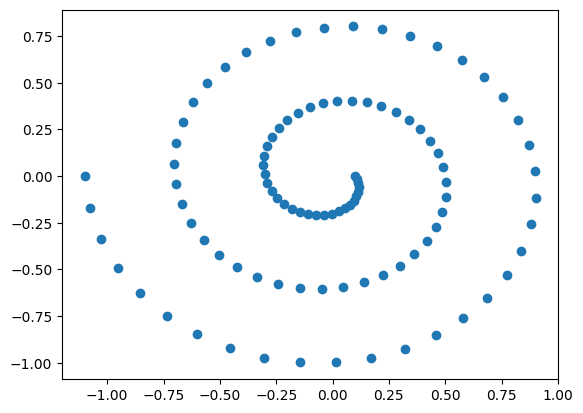

In [52]:
plot_batch(next(iter(swiss_roll_dataloader)))

what does this mean - center = torch.tensor(center).unsqueeze(0)
This line of code center = torch.tensor(center).unsqueeze(0) is doing two main things:

torch.tensor(center): This converts the variable center (whatever its current data type is) into a PyTorch tensor. PyTorch is a library for numerical computation, and tensors are its fundamental data structure, similar to NumPy arrays.
.unsqueeze(0): This method adds a new dimension of size 1 at the specified position (in this case, at index 0, which is the beginning).
So, if center was a 1D tensor, after unsqueeze(0), it becomes a 2D tensor. This is often done to make the tensor compatible with operations that expect a batch dimension (the first dimension in many deep learning frameworks). For example, if center was a single point [x], after unsqueezing it becomes [[x]].


what does this mean - vals = center + scale * torch.stack([t*torch.cos(t)/tmax, t*torch.sin(t)/tmax]).T
This line of code calculates points that form a spiral shape, centered around a specific point. Let's break it down:

t*torch.cos(t)/tmax and t*torch.sin(t)/tmax: These parts calculate the x and y coordinates of points on a spiral. The t variable is likely a tensor representing a range of values (like time or angle) that define the spiral's progression. torch.cos(t) and torch.sin(t) give the circular motion, and multiplying by t makes the radius of the spiral grow over time. Dividing by tmax likely normalizes the values.
torch.stack([...]): This stacks the calculated x and y coordinates into a single tensor. If t has N values, this will result in a tensor of shape [2, N], where the first row is all the x-coordinates and the second row is all the y-coordinates.
.T: This transposes the stacked tensor, changing its shape from [2, N] to [N, 2]. Now, each row represents a point [x, y].
scale * ...: This scales the spiral points by the scale factor. A larger scale will make the spiral larger.
center + ...: This adds the center coordinates to each of the scaled spiral points. This shifts the entire spiral so that it is centered at the center point.
In essence, this line generates a set of 2D points that form a spiral, scaled by scale and shifted by center. This is likely used to create the 1D Swiss roll data by taking a projection of these 2D points.

In [53]:
log_graph = torch.logspace(1, 2, 6)
print(log_graph)

tensor([ 10.0000,  15.8489,  25.1189,  39.8107,  63.0957, 100.0000])


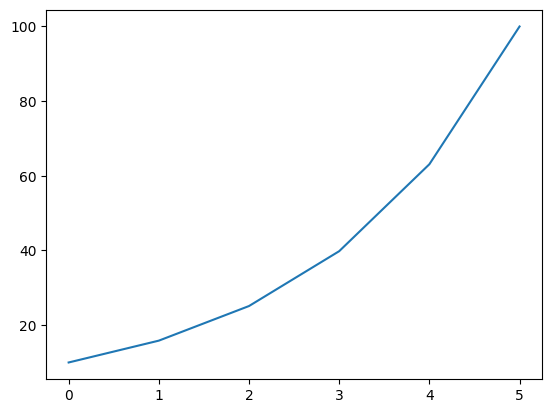

In [54]:
plt.plot(log_graph)

In [55]:
import math
log_graph_log_space = torch.logspace(math.log10(0.01), math.log10(10), 200)
print(log_graph_log_space)

tensor([1.0000e-02, 1.0353e-02, 1.0719e-02, 1.1098e-02, 1.1490e-02, 1.1895e-02,
        1.2316e-02, 1.2751e-02, 1.3201e-02, 1.3667e-02, 1.4150e-02, 1.4650e-02,
        1.5167e-02, 1.5703e-02, 1.6258e-02, 1.6832e-02, 1.7426e-02, 1.8042e-02,
        1.8679e-02, 1.9339e-02, 2.0022e-02, 2.0729e-02, 2.1461e-02, 2.2219e-02,
        2.3004e-02, 2.3817e-02, 2.4658e-02, 2.5529e-02, 2.6431e-02, 2.7364e-02,
        2.8331e-02, 2.9332e-02, 3.0368e-02, 3.1440e-02, 3.2551e-02, 3.3701e-02,
        3.4891e-02, 3.6123e-02, 3.7399e-02, 3.8720e-02, 4.0088e-02, 4.1504e-02,
        4.2970e-02, 4.4488e-02, 4.6059e-02, 4.7686e-02, 4.9370e-02, 5.1114e-02,
        5.2920e-02, 5.4789e-02, 5.6724e-02, 5.8728e-02, 6.0802e-02, 6.2950e-02,
        6.5173e-02, 6.7475e-02, 6.9859e-02, 7.2326e-02, 7.4881e-02, 7.7526e-02,
        8.0264e-02, 8.3099e-02, 8.6035e-02, 8.9074e-02, 9.2220e-02, 9.5477e-02,
        9.8850e-02, 1.0234e-01, 1.0596e-01, 1.0970e-01, 1.1357e-01, 1.1758e-01,
        1.2174e-01, 1.2604e-01, 1.3049e-

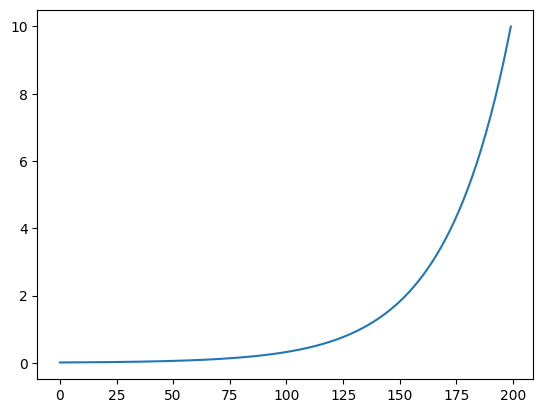

In [56]:
plt.plot(log_graph_log_space)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3989839072.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma_t$')


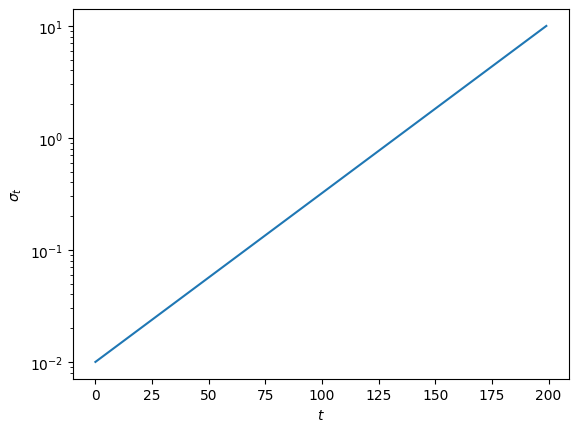

In [57]:
plt.plot(log_graph_log_space)
plt.xlabel('$t$')
plt.ylabel('$\sigma_t$')
plt.yscale('log')

In [58]:
print(len(log_graph_log_space))
for i in range(len(log_graph_log_space)):
    print(i, log_graph_log_space[i])

200
0 tensor(0.0100)
1 tensor(0.0104)
2 tensor(0.0107)
3 tensor(0.0111)
4 tensor(0.0115)
5 tensor(0.0119)
6 tensor(0.0123)
7 tensor(0.0128)
8 tensor(0.0132)
9 tensor(0.0137)
10 tensor(0.0141)
11 tensor(0.0146)
12 tensor(0.0152)
13 tensor(0.0157)
14 tensor(0.0163)
15 tensor(0.0168)
16 tensor(0.0174)
17 tensor(0.0180)
18 tensor(0.0187)
19 tensor(0.0193)
20 tensor(0.0200)
21 tensor(0.0207)
22 tensor(0.0215)
23 tensor(0.0222)
24 tensor(0.0230)
25 tensor(0.0238)
26 tensor(0.0247)
27 tensor(0.0255)
28 tensor(0.0264)
29 tensor(0.0274)
30 tensor(0.0283)
31 tensor(0.0293)
32 tensor(0.0304)
33 tensor(0.0314)
34 tensor(0.0326)
35 tensor(0.0337)
36 tensor(0.0349)
37 tensor(0.0361)
38 tensor(0.0374)
39 tensor(0.0387)
40 tensor(0.0401)
41 tensor(0.0415)
42 tensor(0.0430)
43 tensor(0.0445)
44 tensor(0.0461)
45 tensor(0.0477)
46 tensor(0.0494)
47 tensor(0.0511)
48 tensor(0.0529)
49 tensor(0.0548)
50 tensor(0.0567)
51 tensor(0.0587)
52 tensor(0.0608)
53 tensor(0.0629)
54 tensor(0.0652)
55 tensor(0.0675

In [59]:
import torch

a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])

# Concatenate along dimension 0
cat_dim0 = torch.cat((a, b), dim=0)
print("Concatenated along dim=0:\n", cat_dim0)

# Concatenate along dimension 1
cat_dim1 = torch.cat((a, b), dim=1)
print("Concatenated along dim=1:\n", cat_dim1)

Concatenated along dim=0:
 tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])
Concatenated along dim=1:
 tensor([[1, 2, 5, 6],
        [3, 4, 7, 8]])


In [60]:
print(torch.Size([]))
print(len(torch.Size([])))

torch.Size([])
0


In [61]:
log_graph_log_space.shape

torch.Size([200])

In [62]:
log_graph_log_space.shape == torch.Size([])

False

In [63]:
sigmas = torch.tensor(0)
print(sigmas)

tensor(0)


In [64]:
print(sigmas.shape)

torch.Size([])


In [65]:
sigmas.shape == torch.Size([])

True

In [66]:
sigmas.unsqueeze(0)
# .repeat(len(log_graph_log_space))

tensor([0])

In [67]:
# sigmas.unsqueeze(1)

In [68]:
sigmas.unsqueeze(-1)

tensor([0])

In [69]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])
print(a)
print(a.shape)
print(a.unsqueeze(0))
print(a.unsqueeze(0).shape)
print(a.unsqueeze(1))
print(a.unsqueeze(1).shape)

tensor([1, 2, 3])
torch.Size([3])
tensor([[1, 2, 3]])
torch.Size([1, 3])
tensor([[1],
        [2],
        [3]])
torch.Size([3, 1])


In [70]:
sigmas

tensor(0)

In [71]:
sigmas.unsqueeze(0)

tensor([0])

In [72]:
sigmas.unsqueeze(0).shape

torch.Size([1])

In [73]:
sigmas.unsqueeze(0).repeat(10,1)

tensor([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0]])

In [74]:
sigmas.unsqueeze(0).repeat(10,1).shape

torch.Size([10, 1])

In [75]:
# sigmas.unsqueeze(1).repeat(10,1).shape

In [76]:
sigmas.squeeze(0)

tensor(0)

In [77]:
# print(log_graph_log_space)

In [78]:
import torch

# Example tensor
x = torch.tensor([1.0, torch.e, 10.0])
print(f"x = {x}")
# Compute the natural logarithm
log_x = torch.log(x)

print(f"log_x = {log_x}")

# Example with a negative value (will result in NaN)
y = torch.tensor([-1.0])
print(f"y = {y}")
log_y = torch.log(y)
print(f"log_y = {log_y}")

# Example with zero (will result in -inf)
z = torch.tensor([0.0])
print(f"z = {z}")
log_z = torch.log(z)
print(f"log_z = {log_z}")

x = tensor([ 1.0000,  2.7183, 10.0000])
log_x = tensor([0.0000, 1.0000, 2.3026])
y = tensor([-1.])
log_y = tensor([nan])
z = tensor([0.])
log_z = tensor([-inf])


In [79]:
def get_sigma_embeds(batches, sigma, scaling_factor=0.5, log_scale=True):
    if sigma.shape == torch.Size([]):
        sigma = sigma.unsqueeze(0).repeat(batches)
    else:
        assert sigma.shape == (batches,), 'sigma.shape == [] or [batches]!'
    if log_scale:
        sigma = torch.log(sigma)
    s = sigma.unsqueeze(1) * scaling_factor
    return torch.cat([torch.sin(s), torch.cos(s)], dim=1)

In [80]:
# This is the explaination for the sinusoidal embedding
# The schedule is embedded sinusoidally as
# I also understand from this statement - sigma is noise schedule


In [81]:
# The noise schedule is embedded sinusoidally in DDPMs for a few key reasons:

# Rich Representation: It provides a more informative input to the neural network compared to a single scalar, allowing the model to better distinguish between different noise levels.
# Captures Relationships: The periodic nature of sine and cosine can help the model capture relationships and the progression of noise levels throughout the diffusion process.
# Generalization: It can help the model generalize to noise levels it didn't specifically see during training.
# Essentially, it gives the network a better understanding of "where it is" in the denoising process.

In [82]:
# This means - we first create a log scale noise schedule, then we create
# a sinusoidal noise schedule

tensor(-4.6052)
tensor(2.3026)
tensor(-2.3026)
tensor(1.1513)


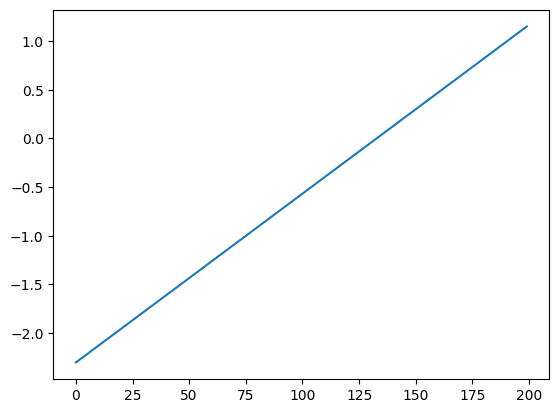

In [83]:
from logging import log
log_sigma_ = torch.log(log_graph_log_space)
print(log_sigma_.min())
print(log_sigma_.max())
# plt.plot(log_sigma_)
# Scale it down to 0.5
log_sigma_by_two = log_sigma_ * 0.5
print(log_sigma_by_two.min())
print(log_sigma_by_two.max())
plt.plot(log_sigma_by_two)

torch.Size([400])
tensor(-1.0000)
tensor(1.0000)


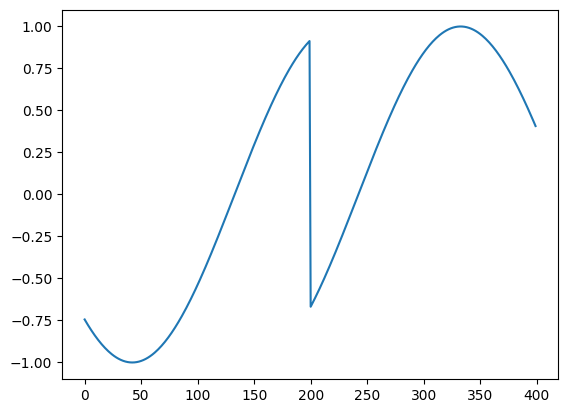

In [84]:
# Dimension=0 means add more rows, dim=1 means add more columns
sinusoidal_embeds = torch.cat(
    [
        torch.sin(log_sigma_by_two),
        torch.cos(log_sigma_by_two)
    ]
)
print(sinusoidal_embeds.shape)
print(sinusoidal_embeds.min())
print(sinusoidal_embeds.max())
plt.plot(sinusoidal_embeds)

torch.Size([400])
tensor(-1.0000)
tensor(1.0000)


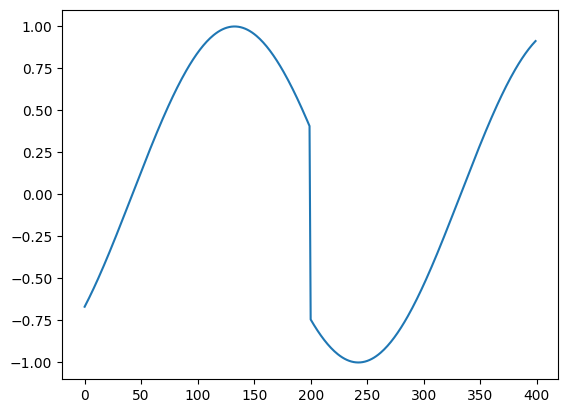

In [85]:
# Dimension=0 means add more rows, dim=1 means add more columns
sinusoidal_embeds = torch.cat(
    [
        torch.cos(log_sigma_by_two),
        torch.sin(log_sigma_by_two),
    ]
)
print(sinusoidal_embeds.shape)
print(sinusoidal_embeds.min())
print(sinusoidal_embeds.max())
plt.plot(sinusoidal_embeds)

In [86]:
list1 = [1, 2, 3]
list2 = [4, 5]

# Using append()
list1.append(list2)
print("After append():", list1)

list3 = [1, 2, 3]
list4 = [4, 5]

# Using extend()
list3.extend(list4)
print("After extend():", list3)

list5 = [1, 2, 3]
string1 = "abc"

# Using extend() with a string
list5.extend(string1)
print("After extend() with string:", list5)

After append(): [1, 2, 3, [4, 5]]
After extend(): [1, 2, 3, 4, 5]
After extend() with string: [1, 2, 3, 'a', 'b', 'c']


In [87]:
import torch

# Create a tensor with dimensions of size 1
x = torch.zeros(1, 2, 1, 3, 1)
print(x)
print("Original tensor shape:", x.shape)

# Squeeze all dimensions of size 1
y = x.squeeze()
print(y)
print("Squeezed tensor shape (all dimensions):", y.shape)

# Squeeze a specific dimension (at index 0)
z = x.squeeze(0)
print("Squeezed tensor shape (dim=0):", z.shape)

# Squeeze a specific dimension (at index 2)
w = x.squeeze(2)
print("Squeezed tensor shape (dim=2):", w.shape)

# Squeeze a dimension that is not of size 1
v = x.squeeze(1)
print("Squeezed tensor shape (dim=1):", v.shape)

tensor([[[[[0.],
           [0.],
           [0.]]],


         [[[0.],
           [0.],
           [0.]]]]])
Original tensor shape: torch.Size([1, 2, 1, 3, 1])
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Squeezed tensor shape (all dimensions): torch.Size([2, 3])
Squeezed tensor shape (dim=0): torch.Size([2, 1, 3, 1])
Squeezed tensor shape (dim=2): torch.Size([1, 2, 3, 1])
Squeezed tensor shape (dim=1): torch.Size([1, 2, 1, 3, 1])


In [88]:
a_list = list(range(5))
print(a_list)

[0, 1, 2, 3, 4]


In [89]:
print('Hi')

Hi


In [90]:
log_graph_log_space.shape

torch.Size([200])

In [91]:
a = torch.randn((1,2))
print(a)

tensor([[0.2345, 0.2303]])


In [92]:
import torch

# Create an input tensor
input_tensor = torch.tensor([[1., 2.], [3., 4.]], dtype=torch.float32, device='cpu')

# Create a new tensor with the same size and properties, filled with random normal numbers
random_tensor = torch.randn_like(input_tensor)

print(f"Input tensor:\n{input_tensor}")
print(f"Random tensor (randn_like):\n{random_tensor}")

# Example with overriding dtype
random_tensor_double = torch.randn_like(input_tensor, dtype=torch.double)
print(f"Random tensor (randn_like with double dtype):\n{random_tensor_double}")

Input tensor:
tensor([[1., 2.],
        [3., 4.]])
Random tensor (randn_like):
tensor([[-1.1229, -0.1863],
        [ 2.2082, -0.6380]])
Random tensor (randn_like with double dtype):
tensor([[0.4617, 0.2674],
        [0.5349, 0.8094]], dtype=torch.float64)


In [93]:
torch.mean(random_tensor)

tensor(0.0653)

In [94]:
torch.var(random_tensor)

tensor(2.1872)